In [6]:
library(data.table)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%




In [9]:
library(ggplot2)

In [14]:
dir_resultados

[1] "/content/buckets/b1/exp//WFresultados"

In [15]:
# ============================================================
# ANÁLISIS ESTADÍSTICO DEL EXPERIMENTO
# ============================================================
PARAM <- list()

# Carpeta de trabajo
base_dir <- "/content/buckets/b1/exp/"

# Carpeta de resultados
PARAM$resultados <- "resultados"

resultados_folder <- paste0("WF", PARAM$resultados)
dir_resultados <- file.path(base_dir, resultados_folder)

# Crear carpeta si no existe
dir.create(
  dir_resultados,
  showWarnings = FALSE
)


# Trabajar dentro de la carpeta de resultados


setwd(
  dir_resultados
)

# ------------------------------------------------------------
# Experimentos
# ------------------------------------------------------------

# WF911: Baseline
# WF912: Canaritos
# WF913: Boruta-LGBM
# WF914: IA

WF_baseline  <- "WF911"
WF_canaritos <- "WF912"
WF_boruta    <- "WF913"
WF_ia        <- "WF914"

cat("Directorio de trabajo:", getwd(), "\n")

cat("\nExperimentos:\n")
cat("  Baseline    :", WF_baseline,  "\n")
cat("  Canaritos   :", WF_canaritos, "\n")
cat("  Boruta-LGBM :", WF_boruta,    "\n")
cat("  IA          :", WF_ia,        "\n")

Directorio de trabajo: /home/ds/buckets/b1/exp/WFresultados 

Experimentos:
  Baseline    : WF911 
  Canaritos   : WF912 
  Boruta-LGBM : WF913 
  IA          : WF914 


In [16]:
list.files()

[1] "comparacion_curvas_promedio.png" "resultados_experimentos.csv"

In [17]:
# ============================================================
# LEER CURVAS PROMEDIO DE LOS 4 EXPERIMENTOS
# ============================================================

experimentos <- list(
    Baseline  = "WF911",
    Canaritos = "WF912",
    Boruta    = "WF913",
    IA        = "WF914"
)

curvas <- rbindlist(
    lapply(
        names(experimentos),
        function(nombre) {

            archivo <- file.path(
                base_dir,
                experimentos[[nombre]],
                "promedio.txt"
            )

            cat("Leyendo:", archivo, "\n")

            tb <- fread(
                archivo,
                sep = "\t"
            )

            tb[
                ,
                experimento := nombre
            ]

            return(tb)
        }
    )
)

setcolorder(
    curvas,
    c(
        "experimento",
        "envios",
        "ganancia_media",
        "ganancia_suavizada_media",
        "desvio"
    )
)

cat("\n============================================================\n")
cat("CURVAS PROMEDIO CARGADAS\n")
cat("============================================================\n\n")

print(curvas)

Leyendo: /content/buckets/b1/exp//WF911/promedio.txt 
Leyendo: /content/buckets/b1/exp//WF912/promedio.txt 
Leyendo: /content/buckets/b1/exp//WF913/promedio.txt 
Leyendo: /content/buckets/b1/exp//WF914/promedio.txt 

CURVAS PROMEDIO CARGADAS

        experimento envios ganancia_media ganancia_suavizada_media    desvio
             <char>  <int>          <num>                    <num>     <num>
     1:    Baseline      1          0.175                       NA 0.4472136
     2:    Baseline      2          0.150                       NA 0.4472136
     3:    Baseline      3          0.125                       NA 0.4472136
     4:    Baseline      4          0.100                       NA 0.4472136
     5:    Baseline      5          0.275                       NA 0.5477226
    ---                                                                     
131748:          IA  32934       -579.350                       NA 0.0000000
131749:          IA  32935       -579.375                       


Gráfico guardado en:
 /home/ds/buckets/b1/exp/WFresultados/comparacion_curvas_promedio.png 


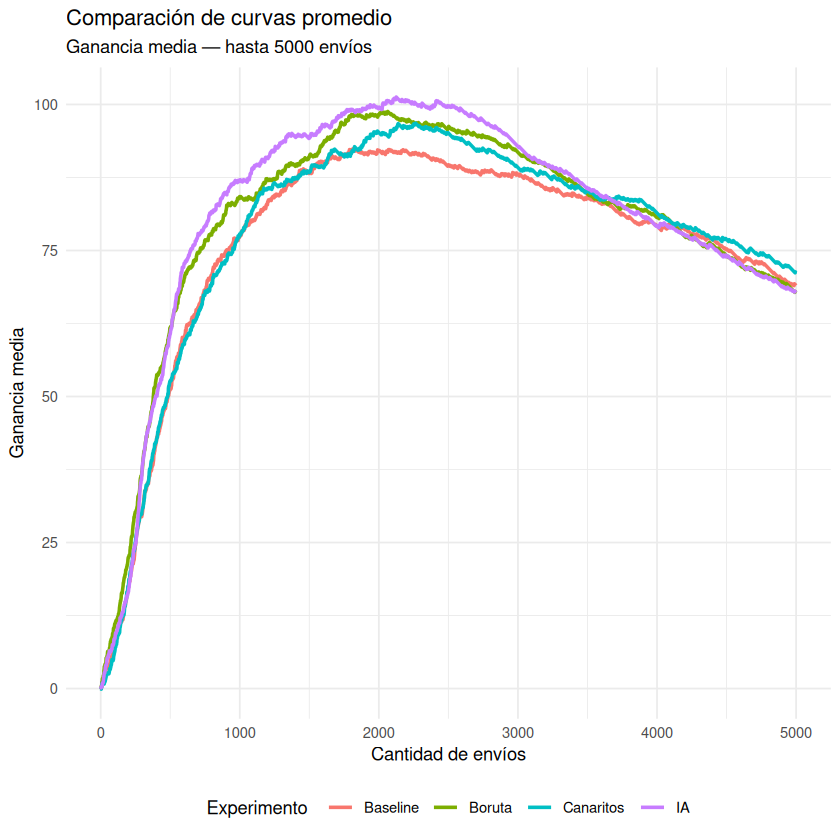

In [11]:
# ============================================================
# GRÁFICO COMPARATIVO DE LAS CURVAS PROMEDIO
# ============================================================

# Cantidad máxima de envíos a mostrar
limite <- 5000


# ------------------------------------------------------------
# Filtrar hasta el límite
# ------------------------------------------------------------

curvas_grafico <- curvas[
    envios <= limite
]


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

p <- ggplot(
    curvas_grafico,
    aes(
        x = envios,
        y = ganancia_media,
        color = experimento
    )
) +
    geom_line(
        linewidth = 1
    ) +
    labs(
        title = "Comparación de curvas promedio",
        subtitle = paste0(
            "Ganancia media — hasta ",
            limite,
            " envíos"
        ),
        x = "Cantidad de envíos",
        y = "Ganancia media",
        color = "Experimento"
    ) +
    theme_minimal() +
    theme(
        legend.position = "bottom"
    )


# ------------------------------------------------------------
# Mostrar en JupyterLab
# ------------------------------------------------------------

print(p)


# ------------------------------------------------------------
# Guardar PNG
# ------------------------------------------------------------

archivo_png <- file.path(
    dir_resultados,
    "comparacion_curvas_promedio.png"
)

ggsave(
    filename = archivo_png,
    plot = p,
    width = 12,
    height = 7,
    dpi = 150
)

cat(
    "\nGráfico guardado en:\n",
    archivo_png,
    "\n"
)

In [18]:
# ============================================================
# PREPARACIÓN DE DATOS PARA EL ANÁLISIS ESTADÍSTICO
# ============================================================

# archivo_datos: Cada fila corresponde a una misma semilla evaluada con los cuatro métodos.

archivo_datos <- file.path(
    dir_resultados,
    "resultados_experimentos.csv"
)

datos <- fread(
    archivo_datos
)

cat("Archivo:", archivo_datos, "\n\n")

cat("Dimensiones:", dim(datos), "\n\n")

print(datos)


# ------------------------------------------------------------
# Verificaciones
# ------------------------------------------------------------

cat("\n============================================================\n")
cat("VERIFICACIONES\n")
cat("============================================================\n")

cat("\nColumnas:\n")
print(names(datos))

cat("\nCantidad de semillas:\n")
print(nrow(datos))

cat("\nSemillas:\n")
print(datos$semilla)

cat("\nValores faltantes:\n")
print(
    datos[
        ,
        lapply(.SD, function(x) sum(is.na(x)))
    ]
)

Archivo: /content/buckets/b1/exp//WFresultados/resultados_experimentos.csv 

Dimensiones: 5 5 

   semilla baseline canaritos boruta_lgbm      ia
     <int>    <num>     <num>       <num>   <num>
1:  291173   94.525    98.600     100.900 101.550
2:  689167   90.800    99.775      98.275 102.225
3:  811501   97.100    98.300     101.950 104.225
4:  500029   93.150    94.750      97.525 102.400
5:  400123   97.350    97.675     102.900 101.750

VERIFICACIONES

Columnas:
[1] "semilla"     "baseline"    "canaritos"   "boruta_lgbm" "ia"         

Cantidad de semillas:
[1] 5

Semillas:
[1] 291173 689167 811501 500029 400123

Valores faltantes:
   semilla baseline canaritos boruta_lgbm    ia
     <int>    <int>     <int>       <int> <int>
1:       0        0         0           0     0


In [19]:
# Test de hipótesis
# H0:μBaseline=μCanaritos=μBoruta-LGBM=μIA

# ============================================================
# TEST DE FRIEDMAN
# ============================================================

cat("============================================================\n")
cat("TEST DE FRIEDMAN\n")
cat("============================================================\n\n")


# ------------------------------------------------------------
# Datos para el test
# ------------------------------------------------------------

matriz_ganancias <- as.matrix(
    datos[
        ,
        .(
            baseline,
            canaritos,
            boruta_lgbm,
            ia
        )
    ]
)


# ------------------------------------------------------------
# Friedman
# ------------------------------------------------------------

resultado_friedman <- friedman.test(
    matriz_ganancias
)


# ------------------------------------------------------------
# Mostrar resultado
# ------------------------------------------------------------

print(resultado_friedman)


# ------------------------------------------------------------
# Guardar resultado
# ------------------------------------------------------------

archivo_friedman <- file.path(
    base_dir,
    paste0("WF", PARAM$resultados),
    "test_friedman.txt"
)

capture.output(
    resultado_friedman,
    file = archivo_friedman
)


cat(
    "\nResultado guardado en:\n",
    archivo_friedman,
    "\n"
)

TEST DE FRIEDMAN


	Friedman rank sum test

data:  matriz_ganancias
Friedman chi-squared = 12.84, df = 3, p-value = 0.004996


Resultado guardado en:
 /content/buckets/b1/exp//WFresultados/test_friedman.txt 


In [ ]:
# Resultó: p = 0.004996 < 0.05

# Rechazamos H0 al nivel de significancia del 5%.
# hay evidencia estadísticamente significativa de que los cuatro métodos NO tienen el mismo comportamiento.

# vamos a hacer tres tests pareados:

# -Baseline vs Canaritos
# -Baseline vs Boruta-LGBM
# -Baseline vs IA

# y aplicar Holm para corregir por las tres comparaciones múltiples.
# Una salvedad: como tenemos solamente 5 semillas, la potencia estadística es limitada.
# Debemos mirar también las diferencias por semilla y un tamaño de efecto, no solamente el p-value.

In [20]:
# ============================================================
# WILCOXON PAREADO CONTRA BASELINE
# ============================================================

cat("============================================================\n")
cat("WILCOXON PAREADO: ALTERNATIVAS VS BASELINE\n")
cat("============================================================\n\n")


# ------------------------------------------------------------
# 1. Wilcoxon Baseline vs Canaritos
# ------------------------------------------------------------

test_canaritos <- wilcox.test(
    datos$canaritos,
    datos$baseline,
    paired = TRUE,
    alternative = "greater",
    exact = TRUE
)


# ------------------------------------------------------------
# 2. Wilcoxon Baseline vs Boruta-LGBM
# ------------------------------------------------------------

test_boruta <- wilcox.test(
    datos$boruta_lgbm,
    datos$baseline,
    paired = TRUE,
    alternative = "greater",
    exact = TRUE
)


# ------------------------------------------------------------
# 3. Wilcoxon Baseline vs IA
# ------------------------------------------------------------

test_ia <- wilcox.test(
    datos$ia,
    datos$baseline,
    paired = TRUE,
    alternative = "greater",
    exact = TRUE
)


# ------------------------------------------------------------
# Mostrar resultados individuales
# ------------------------------------------------------------

cat("Baseline vs Canaritos:\n")
print(test_canaritos)

cat("\nBaseline vs Boruta-LGBM:\n")
print(test_boruta)

cat("\nBaseline vs IA:\n")
print(test_ia)

WILCOXON PAREADO: ALTERNATIVAS VS BASELINE

Baseline vs Canaritos:

	Wilcoxon signed rank exact test

data:  datos$canaritos and datos$baseline
V = 15, p-value = 0.03125
alternative hypothesis: true location shift is greater than 0


Baseline vs Boruta-LGBM:

	Wilcoxon signed rank exact test

data:  datos$boruta_lgbm and datos$baseline
V = 15, p-value = 0.03125
alternative hypothesis: true location shift is greater than 0


Baseline vs IA:

	Wilcoxon signed rank exact test

data:  datos$ia and datos$baseline
V = 15, p-value = 0.03125
alternative hypothesis: true location shift is greater than 0



In [21]:
# ============================================================
# CORRECCIÓN POR COMPARACIONES MÚLTIPLES - HOLM
# ============================================================

p_values <- c(
    Canaritos = test_canaritos$p.value,
    Boruta_LGBM = test_boruta$p.value,
    IA = test_ia$p.value
)


p_values_holm <- p.adjust(
    p_values,
    method = "holm"
)


resultado_wilcoxon <- data.table(
    comparacion = names(p_values),
    p_value = as.numeric(p_values),
    p_value_holm = as.numeric(p_values_holm)
)


# Indicador de significancia
resultado_wilcoxon[
    ,
    significativo := p_value_holm < 0.05
]


cat("============================================================\n")
cat("RESULTADOS WILCOXON + HOLM\n")
cat("============================================================\n\n")

print(resultado_wilcoxon)


# ------------------------------------------------------------
# Guardar
# ------------------------------------------------------------

archivo_wilcoxon <- file.path(
    dir_resultados,
    "test_wilcoxon_vs_baseline.txt"
)


capture.output(
    resultado_wilcoxon,
    file = archivo_wilcoxon
)


cat(
    "\nResultado guardado en:\n",
    archivo_wilcoxon,
    "\n"
)

RESULTADOS WILCOXON + HOLM

   comparacion p_value p_value_holm significativo
        <char>   <num>        <num>        <lgcl>
1:   Canaritos 0.03125      0.09375         FALSE
2: Boruta_LGBM 0.03125      0.09375         FALSE
3:          IA 0.03125      0.09375         FALSE

Resultado guardado en:
 /content/buckets/b1/exp//WFresultados/test_wilcoxon_vs_baseline.txt 


In [ ]:
# Con solamente 5 pares, el Wilcoxon exacto tiene una resolución muy limitada. En un test unilateral, cuando las 5 diferencias tienen el mismo signo, el p-value mínimo posible es:

# p = 1/2**5 = 0.03125

# Por eso los tres dan exactamente 0.03125, aunque las magnitudes de las mejoras sean diferentes.
# Luego, pHolm = 0.03125×3 = 0.09375

# => ninguno alcanza significancia individual al 5% después de Holm. (faltaron semillas !!)

# ¿Podemos demostrar cuál es el mejor? → necesitamos comparaciones post-hoc entre métodos
# => Wilcoxon pareado post-hoc para las 6 parejas

In [22]:
# ============================================================
# WILCOXON PAREADO POST-HOC
# Comparación de todos contra todos
# ============================================================

metodos <- c(
    "baseline",
    "canaritos",
    "boruta_lgbm",
    "ia"
)

comparaciones <- combn(
    metodos,
    2,
    simplify = FALSE
)


resultados_posthoc <- rbindlist(
    lapply(
        comparaciones,
        function(par) {

            metodo_a <- par[1]
            metodo_b <- par[2]

            x <- datos[[metodo_a]]
            y <- datos[[metodo_b]]

            diferencias <- x - y

            test <- wilcox.test(
                x,
                y,
                paired = TRUE,
                alternative = "two.sided",
                exact = TRUE
            )

            data.table(
                metodo_a = metodo_a,
                metodo_b = metodo_b,

                media_a = mean(x),
                media_b = mean(y),

                diferencia_media =
                    mean(diferencias),

                diferencia_mediana =
                    median(diferencias),

                p_value = test$p.value
            )
        }
    )
)


# ------------------------------------------------------------
# Corrección Holm
# ------------------------------------------------------------

resultados_posthoc[
    ,
    p_value_holm :=
        p.adjust(p_value, method = "holm")
]


resultados_posthoc[
    ,
    significativo :=
        p_value_holm < 0.05
]


# ------------------------------------------------------------
# Ordenar por p-value
# ------------------------------------------------------------

setorder(
    resultados_posthoc,
    p_value_holm
)


cat("============================================================\n")
cat("COMPARACIONES POST-HOC\n")
cat("============================================================\n\n")

print(
    resultados_posthoc
)

COMPARACIONES POST-HOC

      metodo_a    metodo_b media_a media_b diferencia_media diferencia_mediana
        <char>      <char>   <num>   <num>            <num>              <num>
1:    baseline   canaritos  94.585   97.82           -3.235             -1.600
2:    baseline boruta_lgbm  94.585  100.31           -5.725             -5.550
3:    baseline          ia  94.585  102.43           -7.845             -7.125
4:   canaritos boruta_lgbm  97.820  100.31           -2.490             -2.775
5:   canaritos          ia  97.820  102.43           -4.610             -4.075
6: boruta_lgbm          ia 100.310  102.43           -2.120             -2.275
   p_value p_value_holm significativo
     <num>        <num>        <lgcl>
1:  0.0625        0.375         FALSE
2:  0.0625        0.375         FALSE
3:  0.0625        0.375         FALSE
4:  0.1250        0.375         FALSE
5:  0.0625        0.375         FALSE
6:  0.1875        0.375         FALSE


In [23]:
# ============================================================
# RESUMEN DESCRIPTIVO POR MÉTODO
# ============================================================

resumen_metodos <- rbindlist(
    lapply(
        metodos,
        function(m) {

            x <- datos[[m]]

            data.table(
                metodo = m,
                media = mean(x),
                mediana = median(x),
                sd = sd(x),
                minimo = min(x),
                maximo = max(x)
            )
        }
    )
)


setorder(
    resumen_metodos,
    -media
)


cat("============================================================\n")
cat("RESUMEN DE GANANCIAS\n")
cat("============================================================\n\n")

print(resumen_metodos)

RESUMEN DE GANANCIAS

        metodo   media mediana       sd  minimo  maximo
        <char>   <num>   <num>    <num>   <num>   <num>
1:          ia 102.430 102.225 1.060866 101.550 104.225
2: boruta_lgbm 100.310 100.900 2.326115  97.525 102.900
3:   canaritos  97.820  98.300 1.877948  94.750  99.775
4:    baseline  94.585  94.525 2.754973  90.800  97.350


In [ ]:
# =>
# Conclusiones:
# ninguna diferencia individual es estadísticamente significativa después de Holm!!
# pero Friedman se sigue cumpliendo: los 4 métodos no tienen idem desempeño
# y la tabla resumen lo avala
# pero,....faltaron semillas!

# La IA presentó el mejor desempeño observado, con una ganancia media de 102.43, seguida por Boruta-LGBM (100.31), Canaritos (97.82) y Baseline (94.585).